<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/DBSCAN_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Machine Learning Blueprint: DBSCAN Anomaly Detection
> **Purpose:** Reference manual for feature verification, algorithmic review, and pipeline testing.

---

## 1. Algorithmic Architecture & Mathematical Foundations

Unlike distance-from-mean models (e.g., K-Means), **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) models data spaces as dense geometric topologies separated by voids of low density.

### A. Distance Metrics
The localized proximity between any two multi-dimensional feature points $x_i$ and $x_j$ across an $m$-dimensional space is computed via the **Euclidean Distance Formula**:

$$d(x_i, x_j) = \sqrt{\sum_{k=1}^{m} (x_{ik} - x_{jk})^2}$$

### B. Neighborhood Proximity Rule
For any target point $P$, its bounded spatial environment $N_{\epsilon}(P)$ represents the set of all elements residing inside a maximum radius threshold $\epsilon$:

$$N_{\epsilon}(P) = \{ q \in X \mid d(P, q) \le \epsilon \}$$

### C. Structural Criteria for Anomalies
DBSCAN defines an anomaly explicitly as a **Noise Point**. A data point is cast out as an anomaly if and only if it fails both cluster membership rules simultaneously:

1. **Density Threshold Deficit:** Its immediate radius lacks the minimum configuration of points ($\text{MinPts}$):
$$\lvert N_{\epsilon}(P) \rvert < \text{MinPts}$$

2. **Reachability Disconnection:** It does not reside within the neighborhood radius of any active valid core hub point $C$:
$$P \notin N_{\epsilon}(C) \quad \forall \quad C \in \{\text{Core Points}\}$$


## 2. Strategic Trade-offs (Pros & Cons)

### Advantages (Pros)
* **Arbitrary Boundary Resolution:** Maps complex, irregular anomaly profiles (e.g., rings, waves, overlapping filaments) that completely break centroid-based models.
* **No Pre-calculated Cluster Estimations:** Eliminates the necessity to declare or guess the total number of expected groupings ($K$) prior to fitting.
* **Deterministic Noise Isolation:** Isolates outliers directly under an exclusive categorical index (`-1`), preventing skewing of normal grouping boundaries.
* **High Contrast Filtering:** Naturally filters out scattered wide-area noise while preserving ultra-specific high-density clusters.

### Disadvantages (Cons)
* **Multi-Density Blind Spot:** Fails to isolate anomalies accurately if the underlying dataset contains legitimate groups with varying baseline densities.
* **Dimensional Proximity Decay:** Suffers from the "curse of dimensionality" as spatial Euclidean metrics flatten and lose significance in ultra-high dimensional zones.
* **Hyperparameter Volatility:** Minor scale shifts in $\epsilon$ or minimum density counters can trigger extreme variations, shifting points from normal borders to severe anomalies.
* **Pairwise Scalability Ceiling:** Standard distance scanning requires an $O(N^2)$ computational runtime profile unless accelerated using Spatial Index Trees (like KD-Trees).



# ***Impelement DBSCAN Clustering Anomaly Detection***

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
from sklearn.datasets import make_circles
x,y=make_circles(n_samples=750,factor=0.3,noise=0.1)

In [3]:
x

array([[ 0.88324627,  0.05660211],
       [-0.47573293, -0.91513589],
       [ 0.22564091,  0.2082871 ],
       ...,
       [-0.34331538, -0.97314395],
       [ 0.69325689,  0.56651306],
       [ 0.30192976,  0.00852933]])

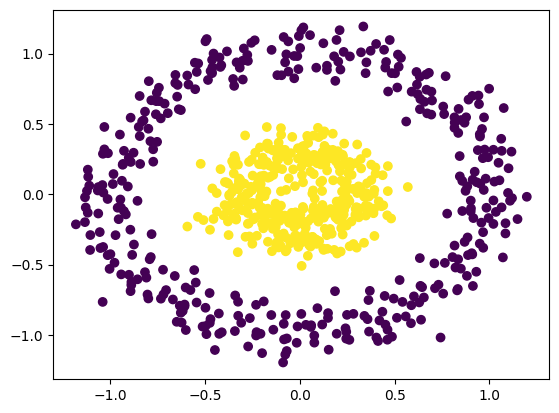

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=y)

In [5]:
dbscan=DBSCAN(eps=0.10,min_samples=5)
dbscan.fit_predict(x)

array([ 0,  1,  2,  3,  2, -1,  8,  2,  2,  2,  2,  2,  2,  0,  0,  4,  5,
        2,  2,  2,  6,  2,  2, -1, -1,  7,  2,  8,  2,  0,  5,  2,  4,  2,
       12,  5,  2,  4,  2,  2,  2,  0,  2,  2,  0,  2,  0,  6,  2,  2,  2,
        9, 10,  2,  2,  2,  2,  2, -1, -1,  9,  2,  5,  3, 11, -1,  2,  9,
        3,  2,  2, 12,  2,  2,  5, 11,  2,  2,  2,  4,  6,  2,  5,  3, 11,
        2,  2,  2,  0,  2, 11,  2,  2,  2,  5,  2,  0,  5, 11,  2,  2,  2,
        2, -1,  2, 11,  2,  2, 10,  7,  2, -1, 10, 12,  4,  2,  3,  2,  2,
        6, 10,  2,  2,  2,  2,  8,  2,  2,  9,  2,  2,  2,  2,  2,  0,  2,
        2,  4,  0,  3,  2,  2,  0,  3, -1,  5, 10,  2,  0,  2,  6,  2,  8,
        2, 12,  2,  0, 10,  6,  2,  2,  2,  4, -1, 10,  2,  3,  2,  8, -1,
        5, -1,  8,  8,  4,  2,  4,  2,  2,  2,  2,  0,  5,  8,  2,  2,  2,
        2,  0,  2,  2,  9,  5,  5,  0,  2,  2,  2,  5,  2,  1,  8,  2,  2,
        2,  2,  2,  4,  2,  2,  6,  2,  2,  3,  2, 12,  2,  2,  2,  2,  2,
        6, 10,  2,  2,  4

In [6]:
dbscan.labels_

array([ 0,  1,  2,  3,  2, -1,  8,  2,  2,  2,  2,  2,  2,  0,  0,  4,  5,
        2,  2,  2,  6,  2,  2, -1, -1,  7,  2,  8,  2,  0,  5,  2,  4,  2,
       12,  5,  2,  4,  2,  2,  2,  0,  2,  2,  0,  2,  0,  6,  2,  2,  2,
        9, 10,  2,  2,  2,  2,  2, -1, -1,  9,  2,  5,  3, 11, -1,  2,  9,
        3,  2,  2, 12,  2,  2,  5, 11,  2,  2,  2,  4,  6,  2,  5,  3, 11,
        2,  2,  2,  0,  2, 11,  2,  2,  2,  5,  2,  0,  5, 11,  2,  2,  2,
        2, -1,  2, 11,  2,  2, 10,  7,  2, -1, 10, 12,  4,  2,  3,  2,  2,
        6, 10,  2,  2,  2,  2,  8,  2,  2,  9,  2,  2,  2,  2,  2,  0,  2,
        2,  4,  0,  3,  2,  2,  0,  3, -1,  5, 10,  2,  0,  2,  6,  2,  8,
        2, 12,  2,  0, 10,  6,  2,  2,  2,  4, -1, 10,  2,  3,  2,  8, -1,
        5, -1,  8,  8,  4,  2,  4,  2,  2,  2,  2,  0,  5,  8,  2,  2,  2,
        2,  0,  2,  2,  9,  5,  5,  0,  2,  2,  2,  5,  2,  1,  8,  2,  2,
        2,  2,  2,  4,  2,  2,  6,  2,  2,  3,  2, 12,  2,  2,  2,  2,  2,
        6, 10,  2,  2,  4

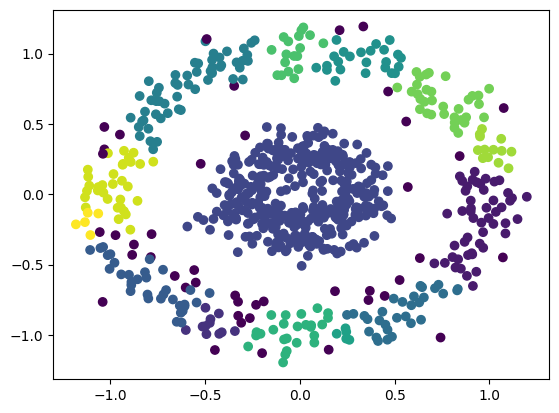

In [7]:
plt.scatter(x[:,0],x[:,1],c=dbscan.labels_)